<a href="https://colab.research.google.com/github/LoneWolf2026/Neural-Network-for-Nuclear-Binding-Energy-Prediction-/blob/main/Semi_Empirical_Mass_Formula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import Atomic Mass Evaluation Dataset here
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

data_df_2020 = pd.read_csv('/content/drive/MyDrive/AME_Dataset_2020.csv',header =None)
data_df_2020 = data_df_2020.drop([0, 1]).reset_index(drop=True) #Drop first two rows (first two rows are individual proton and neutron)

data_df_2016 = pd.read_csv('/content/drive/MyDrive/AME_Dataset_2016.csv',header =None)
data_df_2016 = data_df_2016.drop([0, 1]).reset_index(drop=True) #Same as above

data_df_2016.name = "AME_2016"
data_df_2020.name = "AME_2020"

In [3]:
data_df_2020.head()
data_df_2016.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0,1,1,2,H,13135.72176,0.00011,1112.283,0.0,14101.77811,0.00012
1,1,2,1,3,H,14949.80993,0.00022,2827.265,0.0,16049.28199,0.00023
2,-1,1,2,3,He,14931.21793,0.00021,2572.680,0.0,16029.32265,0.00022
3,-3,0,3,3,Li,28667.00000,2000.00000,-2267.000,667.0,30775.00000,2147.00000
4,2,3,1,4,H,24621.12700,100.00000,1720.449,25.0,26431.86800,107.35400


In [4]:
#Two papers I found have two different Semi Empirical Mass Formula (SEMF) coefficients (one based on AME2016 and the second based on AME2020 results). I decided to include both.

#Each set of coefficients will use the corresponding dataset from which they were derived

#All coefficients are in MeV.


def SEMF_2016(A,Z,delta):

  #Coefficients and pairing term from:
  #Source: Benzaid D., et al. (2020)

  a_v = 14.6433
  a_s = 14.0788
  a_c = 0.6442
  a_sym = 21.0680
  a_p = 11.5398

  binding_energy = a_v*A - a_s*(A**(2/3)) - a_c*(Z**2)/(A**(1/3)) - a_sym*(((A-2*Z)**2)/A) + delta*a_p*(1/(A**(1/2)))

  return binding_energy

def SEMF_2020(A,Z,delta):

  #Coefficients and pairing term from:
  #Gjorgievska S., et al. (2024)

  a_v = 15.582546
  a_s = 17.377737
  a_c = 0.706489
  a_sym = 22.973123
  a_p = 13.013764

  binding_energy = a_v*A - a_s*(A**(2/3)) - a_c*(Z*(Z-1)/(A**(1/3))) - a_sym*(((A-2*Z)**2)/A) + delta*a_p*(1/(A**(1/2)))

  return binding_energy


def Binding_Energy_AME(data_df):
  N = data_df.iloc[:,1] #Neutrons
  Z = data_df.iloc[:,2] #Protons
  A = data_df.iloc[:,3] #Mass Number

  BE_per_Nucleon = []
  binding_energy = 0

  for i in range(len(N)):

    #delta is +- 1 or 0 depending on nucleon parity

    if N[i]%2 == 0 and Z[i]%2 == 0:
      delta = 1
    elif A[i]%2 == 1:
      delta = 0
    elif N[i]%2 == 1 and Z[i]%2 == 1:
      delta = -1

    if data_df.name == "AME_2016":
      binding_energy = SEMF_2016(A[i],Z[i],delta)

    elif data_df.name == "AME_2020":
      binding_energy = SEMF_2016(A[i],Z[i],delta)

    binding_energy_per_nucleon = round(binding_energy/A[i],4)
    BE_per_Nucleon.append(binding_energy_per_nucleon)

  return BE_per_Nucleon #return list of Binding Energies per Nucleon


In [8]:
Prediction_Accuracy = []
Actual_BE_2016 = data_df_2016.iloc[:,7]
Actual_BE_2020 = data_df_2020.iloc[:,7]

BEs_per_A_2016 = Binding_Energy_AME(data_df_2016)
BEs_per_A_2020 = Binding_Energy_AME(data_df_2020)

Nucleons2016 = list(data_df_2016.iloc[:,3]) #Convert data table into list to plot for matplotlib
Nucleons2020 = list(data_df_2020.iloc[:,3]) #Same as above

for a in range(len(BEs_per_A_2016)):
  acc = 100 - abs((BEs_per_A_2016[a] - Actual_BE_2016[a])/Actual_BE_2016[a])*100 #acc for accuracy, in percent
  Prediction_Accuracy.append(acc)

print(Prediction_Accuracy) #Recheck accuracy measurements/calculations
print(Actual_BE_2016)
print(BEs_per_A_2016)


Nucleons2016 = [Nucleons2016[b] for b in range(len(Nucleons2016)) if BEs_per_A_2016[b] > 0] #Remove nucleons with negative, predicted binding energy
BEs_per_A_2016 = [k for k in BEs_per_A_2016 if k > 0] #Remove negative, predicted binding energies



Nucleons2020 = [Nucleons2020[b] for b in range(len(Nucleons2020)) if BEs_per_A_2020[b] > 0] #Same as above
BEs_per_A_2020 = [k for k in BEs_per_A_2020 if k > 0] #Same as above

[np.float64(-0.0779118263967149), np.float64(0.0845976588681907), np.float64(0.07560986986334228), np.float64(0.7731098367887199), np.float64(-0.06025752579705568), np.float64(0.09628190330248287), np.float64(-0.16020662876161396), np.float64(-0.09353025646552737), np.float64(0.09553290813791193), np.float64(0.09284043772545658), np.float64(-13.222222222222229), np.float64(-0.34445358393327297), np.float64(0.10460961615605413), np.float64(0.1046165363703011), np.float64(0.0979308694172687), np.float64(1.0129550321199048), np.float64(-0.37378723404255254), np.float64(0.0781313476869343), np.float64(0.11452189170346116), np.float64(0.11325971582122918), np.float64(0.062132152004735985), np.float64(0.06843639476929297), np.float64(0.10494384182682381), np.float64(0.1057666371442707), np.float64(0.10113299223790762), np.float64(0.045055269602940484), np.float64(0.036870300328132544), np.float64(0.10370267150054246), np.float64(0.1093077967179994), np.float64(0.10794988708772735), np.float6

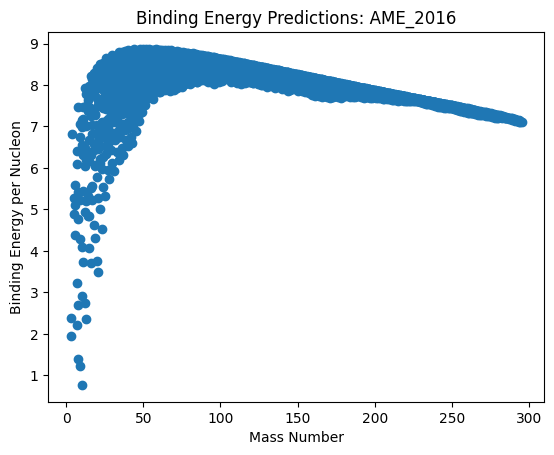

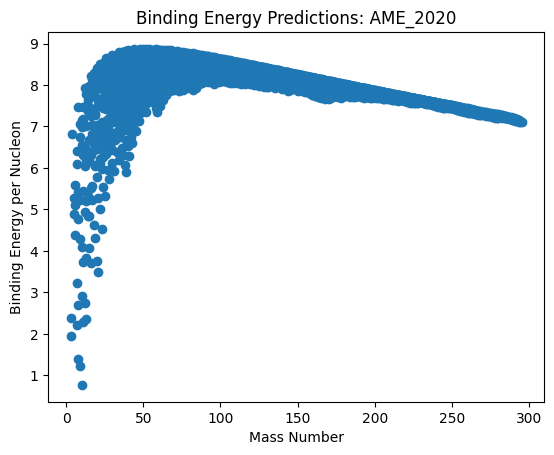

In [ ]:
import matplotlib.pyplot as plt

#x axis is Mass Number(s)
#y axis is in MeV per Nucleon

x1 = Nucleons2016
y1 = BEs_per_A_2016

plt.figure(1)
plt.scatter(x1,y1)
plt.xlabel('Mass Number')
plt.ylabel('Binding Energy per Nucleon')
plt.title('Binding Energy Predictions: AME_2016')
plt.show()


x2 = Nucleons2020
y2 = BEs_per_A_2020

plt.figure(2)
plt.scatter(x2,y2)
plt.xlabel('Mass Number')
plt.ylabel('Binding Energy per Nucleon')
plt.title('Binding Energy Predictions: AME_2020')
plt.show()

